### Macro economics analysis
* Now that we have analysed indices next we are going to analyze macro economic factors analysis consisting of:
  * Interest rates
  * CPI
  * WPI

In [98]:
import os
import pandas as pd
import numpy as np


### Interest Rates Analysis
* Data Quality Checks
* Surprise Analysis
* Regime Analysis
* Number of cycles
* Which regime dominated most
* Market response based on surprises

In [99]:
cwd = os.getcwd()
dataset_folder_path = os.path.join(cwd, "..\\data_clean")
dataset_path = os.path.join(dataset_folder_path, "interest_rates.csv")
interest_rate_df = pd.read_csv(dataset_path)

interest_rate_df.head()


,release_date,actual,forecast,previous
0,05-06-2026,0.0525,0.0525,0.0525
1,08-04-2026,0.0525,0.0525,0.0525
2,06-02-2026,0.0525,0.0525,0.0525
3,05-12-2025,0.0525,0.0525,0.0550
4,01-10-2025,0.0550,0.0550,0.0550


In [100]:
interest_rate_df['release_date'] = pd.to_datetime(
    interest_rate_df['release_date'], format='%d-%m-%Y')


### Data Quality Checks

In [101]:
print(f"Missing values:\n{interest_rate_df.isna().sum()}\n")
print(f"Duplicates count:\n{interest_rate_df.duplicated().sum()}")


Missing values:
release_date     0
actual           0
forecast        52
previous         0
dtype: int64

Duplicates count:
0


#### Observation:
* There are entries where forecast data is missing
* NO duplicate counts

### Regime Analysis

In [102]:
# Lets analyze how long which regime lasted
def analyze_regime(row):
    actual = row["actual"]
    forecast = row["forecast"]
    prev = row["previous"]

    # Scenario 1: They raised rates OR they held it higher than the market expected
    if (actual > prev) or (actual > forecast):
        return "Hawkish"

    # Scenario 2: They cut rates OR they held it lower than the market expected
    elif (actual < prev) or (actual < forecast):
        return "Dovish"

    # Scenario 3: No change from previous, and exactly what the market expected
    else:
        return "Flat"


In [103]:
interest_rate_df["regime"] = interest_rate_df.apply(analyze_regime, axis=1)

# Lets see the regime counts
interest_rate_df['regime'].value_counts()


regime
Flat       72
Hawkish    38
Dovish     33
Name: count, dtype: int64

### Observation:
* Majority of time regime is flat

In [104]:
# Lets analyze longest hawkish & dovish regimes
def get_longest_calendar_streak(data, target_regime):
    # Create a boolean series for the target regime
    is_target = data["regime"] == target_regime

    # Group contiguous blocks of the same regime
    blocks = (is_target != is_target.shift()).cumsum()

    # Create a dictionary to hold stats for each block
    block_stats = []

    # Iterate through each unique block of the target regime
    for block_id, group in data[is_target].groupby(blocks):
        start_date = group["release_date"].min()
        end_date = group["release_date"].max()

        # Calculate calendar duration in days
        duration_days = (end_date - start_date).days

        block_stats.append(
            {
                "regime": target_regime,
                "start_date": start_date,
                "end_date": end_date,
                "duration_days": duration_days,
                "record_count": len(group),
            }
        )

    if not block_stats:
        return None

    # Convert to DataFrame and find the block with the maximum calendar duration (days)
    stats_df = pd.DataFrame(block_stats)
    longest_streak = stats_df.loc[stats_df["duration_days"].idxmax()]
    return longest_streak


In [105]:
hawkish_streak = get_longest_calendar_streak(interest_rate_df, "Hawkish")
dovish_streak = get_longest_calendar_streak(interest_rate_df, "Dovish")

# 4. Display the results
print("=" * 55)
print("        LONGEST REGIME STREAKS (BY CALENDAR TIME)      ")
print("=" * 55)

for streak in [hawkish_streak, dovish_streak]:
    if streak is not None:
        print(f"Regime:            {streak['regime']}")
        print(
            f"Timeline:          {
                streak['start_date'].strftime('%Y-%m-%d')}  to  {
                streak['end_date'].strftime('%Y-%m-%d')}")
        print(f"Calendar Duration: {streak['duration_days']} days")
        print(f"Data Points Count: {streak['record_count']} records")
        print("-" * 55)
    else:
        print("No periods found for this regime.\n")


        LONGEST REGIME STREAKS (BY CALENDAR TIME)      
Regime:            Hawkish
Timeline:          2011-02-01  to  2011-12-01
Calendar Duration: 303 days
Data Points Count: 11 records
-------------------------------------------------------
Regime:            Dovish
Timeline:          2019-02-07  to  2019-10-04
Calendar Duration: 239 days
Data Points Count: 5 records
-------------------------------------------------------


### Observation
* The biggest bull run was observed during post 2008 crash in 2011 due to which market was quite **Hawkish**

* Main reasons for consecutive interest rate cuts in 2019 are:
  *  India’s GDP growth was slowing through 2018–19 and 2019–20.
  *  The RBI targets CPI inflation around 4%, with a tolerance band of 2%–6%.
  *  After the IL&FS crisis in 2018, India’s NBFC sector faced liquidity stress.
  *  Businesses were cautious due to weak demand, stressed balance sheets, and uncertainty.
  *  In 2019, global growth was weakening due to US–China trade tensions and lower world trade.

### Surprise Analysis

In [106]:
interest_rate_df['surprise'] = (interest_rate_df['actual'] - interest_rate_df['forecast']) * 10000


In [107]:
interest_rate_df[interest_rate_df['surprise'] != 0]


,release_date,actual,forecast,previous,regime,surprise
6,2025-06-06,0.0550,0.0575,0.0600,Dovish,-25.0
19,2023-04-06,0.0650,0.0675,0.0650,Dovish,-25.0
23,2022-08-05,0.0540,0.0525,0.0490,Hawkish,15.0
24,2022-06-08,0.0490,0.0480,0.0440,Hawkish,10.0
25,2022-05-04,0.0440,0.0400,0.0440,Hawkish,40.0
...,...,...,...,...,...,...
138,2008-05-01,0.0775,NaN,0.0775,Flat,NaN
139,2008-04-01,0.0775,NaN,0.0775,Flat,NaN
140,2008-03-01,0.0775,NaN,0.0775,Flat,NaN
141,2008-02-01,0.0775,NaN,0.0775,Flat,NaN


In [108]:
# We will replace NAN values with 0 for suprise fields
interest_rate_df['surprise'] = interest_rate_df['surprise'].fillna(0)


In [109]:
surprise_dates = interest_rate_df.loc[interest_rate_df['surprise'] != 0, 'release_date']
surprise_dates[:5]


6    2025-06-06
19   2023-04-06
23   2022-08-05
24   2022-06-08
25   2022-05-04
Name: release_date, dtype: datetime64[us]

#### Comparing market reaction with surprise dates

In [110]:
market_data = os.path.join(dataset_folder_path, 'market_index.csv')
market_df = pd.read_csv(market_data)


In [111]:
# Ensuring dates are in correct format
market_df['date'] = pd.to_datetime(market_df['date'], format='%d-%m-%Y')

market_df.head()


,date,close
0,2008-01-01,3220.99
1,2008-01-02,3282.05
2,2008-01-03,3284.43
3,2008-01-04,3306.04
4,2008-01-07,3330.91


In [112]:
# Computing returns per day in market
market_df['return(%)'] = market_df['close'].pct_change() * 100


# Lets merge the datasets to understand better

# Before we merge we need to ensure joining column has same name
interest_rate_df.rename(columns={'release_date': 'date'}, inplace=True)


In [113]:
# Sort the dataframes before merging

# 1. Sort and save the left DataFrame
interest_rate_df = interest_rate_df.sort_values(by='date')

# 2. Sort and save the right DataFrame (merge_asof requires both to be sorted)
market_df = market_df.sort_values(by='date')

# 3. Perform the merge
merged_interest_df = pd.merge_asof(
    interest_rate_df,
    market_df,
    on='date',
    direction='forward'
)

merged_interest_df.head()


,date,actual,forecast,previous,regime,surprise,close,return(%)
0,2008-01-01,0.0775,NaN,0.0775,Flat,0.0,3220.99,NaN
1,2008-02-01,0.0775,NaN,0.0775,Flat,0.0,2477.82,0.550675
2,2008-03-01,0.0775,NaN,0.0775,Flat,0.0,2336.79,-4.254247
3,2008-04-01,0.0775,NaN,0.0775,Flat,0.0,2008.89,-0.616911
4,2008-05-01,0.0775,NaN,0.0775,Flat,0.0,2298.03,1.434543


In [114]:
# Now lets see how market peformed during surprise
surprise_df = merged_interest_df.loc[merged_interest_df['surprise'] != 0, [
    'date', 'actual', 'forecast', 'surprise', 'return(%)']]

# Finding data when index move more than 1% due to results
surprise_df.loc[surprise_df['return(%)'].abs() >= 1]


,date,actual,forecast,surprise,return(%)
52,2012-06-18,0.0800,0.0775,25.0,-1.099538
63,2013-10-29,0.0775,0.0750,25.0,1.467978
64,2013-12-18,0.0775,0.0800,-25.0,1.360519
71,2015-01-15,0.0775,0.0800,-25.0,1.087544
73,2015-03-04,0.0750,0.0775,-25.0,-1.095770
93,2018-06-06,0.0625,0.0600,25.0,1.280219
95,2018-10-05,0.0650,0.0675,-25.0,-2.611420
106,2020-08-06,0.0400,0.0375,25.0,1.115744
117,2022-05-04,0.0440,0.0400,40.0,-2.050714


### Reason for big crash on 5th Oct 2018 and 4th May 2022


* Oct 5, 2018 fell by -2.61% as RBI changed stance to "Calibrated Tightening"; Rupee hit 74/$ and fragile market due to IL&FS crisis and rising oil prices.

* May 4, 2022 fell by -2.05%	due to surprise 40 bps off-cycle rate hike + 50 bps CRR hike to fight inflation which shocked by the end of low-interest-rate

In [115]:
merged_interest_df.dtypes


date         datetime64[us]
actual              float64
forecast            float64
previous            float64
regime                  str
surprise            float64
close               float64
return(%)           float64
dtype: object

In [116]:
# Lets analyze correlation b/n interest rates declartaion & market reaction
non_str_cols = merged_interest_df.select_dtypes(exclude=['object', 'string']).columns.tolist()

merged_interest_df_corr = merged_interest_df[non_str_cols].corr()
merged_interest_df_corr['actual']


date        -0.393827
actual       1.000000
forecast     0.993000
previous     0.982513
surprise    -0.014391
close       -0.322247
return(%)   -0.102745
Name: actual, dtype: float64

There is weak correlation b/n **actual interest** rates declared & **returns**.

### WPI Analysis
- Missing & duplicate values analysis
- Inflation cycle
- Split of inflation cycles(low, medium,high)
- Longest spread of each cycle
- Relation of WPI with interest rates

In [117]:
wpi_df_path = os.path.join(dataset_folder_path, "wpi.csv")
wpi_df = pd.read_csv(wpi_df_path)

wpi_df.tail()


,release_date,actual,forecast,previous
217,01-05-08,0.0786,NaN,0.0771
218,01-04-08,0.0771,NaN,0.0568
219,01-03-08,0.0568,NaN,0.0454
220,01-02-08,0.0454,NaN,0.0401
221,01-01-08,0.0401,NaN,0.0373


In [118]:
wpi_df['release_date'] = pd.to_datetime(wpi_df['release_date'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_5832\2769715799.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wpi_df['release_date'] = pd.to_datetime(wpi_df['release_date'])


In [119]:
# Missing & duplicates analysis

print("Missing Values:\n", wpi_df.isna().sum())
print("\nDuplicate Counts:", wpi_df.duplicated().sum())


Missing Values:
 release_date     0
actual           0
forecast        43
previous         0
dtype: int64

Duplicate Counts: 0


### Inflation Analysis

In [120]:
def categorize_wpi(value):
    if value <= 0.03:
        return "Low"
    elif value <= 0.06:
        return "Stable"
    else:
        return "High"


wpi_df["inflation_category"] = wpi_df["actual"].apply(categorize_wpi)

wpi_df.head()


,release_date,actual,forecast,previous,inflation_category
0,2026-06-15,0.0968,0.0910,0.0830,High
1,2026-05-14,0.0830,0.0440,0.0388,High
2,2026-04-15,0.0388,0.0300,0.0213,Stable
3,2026-03-16,0.0213,0.0200,0.0181,Low
4,2026-02-16,0.0181,0.0125,0.0083,Low


In [121]:
# Number of inflation cycles
print("Inflation Cycles Count:\n", wpi_df['inflation_category'].value_counts())
cycles_perc = (wpi_df['inflation_category'].value_counts()/wpi_df.shape[0])*100

print("\nInflation Cycles in Percentage:\n", cycles_perc)


Inflation Cycles Count:
 inflation_category
Low       94
High      78
Stable    50
Name: count, dtype: int64

Inflation Cycles in Percentage:
 inflation_category
Low       42.342342
High      35.135135
Stable    22.522523
Name: count, dtype: float64


In [122]:
# Computing streak lengths
# Lets analyze longest hawkish & dovish regimes
def get_longest_calendar_streak(data, target_regime):
    # Create a boolean series for the target regime
    is_target = data["inflation_category"] == target_regime

    # Group contiguous blocks of the same regime
    blocks = (is_target != is_target.shift()).cumsum()

    # Create a dictionary to hold stats for each block
    block_stats = []

    # Iterate through each unique block of the target regime
    for block_id, group in data[is_target].groupby(blocks):
        start_date = group["release_date"].min()
        end_date = group["release_date"].max()

        # Calculate calendar duration in days
        duration_days = (end_date - start_date).days

        block_stats.append(
            {
                "inflation_category": target_regime,
                "start_date": start_date,
                "end_date": end_date,
                "duration_days": duration_days,
                "record_count": len(group),
            }
        )

    if not block_stats:
        return None

    # Convert to DataFrame and find the block with the maximum calendar duration (days)
    stats_df = pd.DataFrame(block_stats)
    longest_streak = stats_df.loc[stats_df["duration_days"].idxmax()]
    return longest_streak


In [123]:
high_streak = get_longest_calendar_streak(wpi_df, "High")
low_streak = get_longest_calendar_streak(wpi_df, "Low")

# 4. Display the results
print("=" * 55)
print("        LONGEST REGIME STREAKS (BY CALENDAR TIME)      ")
print("=" * 55)

for streak in [high_streak, low_streak]:
    if streak is not None:
        print(f"Inflation Category:            {streak['inflation_category']}")
        print(
            f"Timeline:          {
                streak['start_date'].strftime('%Y-%m-%d')}  to  {
                streak['end_date'].strftime('%Y-%m-%d')}")
        print(f"Calendar Duration: {streak['duration_days']} days")
        print(f"Data Points Count: {streak['record_count']} records")
        print("-" * 55)
    else:
        print("No periods found for this regime.\n")


        LONGEST REGIME STREAKS (BY CALENDAR TIME)      
Inflation Category:            High
Timeline:          2010-01-01  to  2013-03-14
Calendar Duration: 1168 days
Data Points Count: 39 records
-------------------------------------------------------
Inflation Category:            Low
Timeline:          2014-10-14  to  2016-07-14
Calendar Duration: 639 days
Data Points Count: 22 records
-------------------------------------------------------


### Observations
* Post 2008 Crash during recovery cycle as there was boom the WPI got increased
* Post Oct 2014 the boom stopped and there was low inflation

### Comparing inflation with WPI & its relationship

In [124]:
interest_rate_df_path = os.path.join(dataset_folder_path, "interest_rates.csv")
interest_rate_df = pd.read_csv(interest_rate_df_path)

interest_rate_df.head()


,release_date,actual,forecast,previous
0,05-06-2026,0.0525,0.0525,0.0525
1,08-04-2026,0.0525,0.0525,0.0525
2,06-02-2026,0.0525,0.0525,0.0525
3,05-12-2025,0.0525,0.0525,0.0550
4,01-10-2025,0.0550,0.0550,0.0550


In [125]:
interest_rate_df['release_date'] = pd.to_datetime(
    interest_rate_df['release_date'], format='%d-%m-%Y')


In [126]:
# To avoid confusion b/n interest rate columns & wpi columns  lets change column names
interest_rate_df.rename(columns={'actual': 'interest_rate'}, inplace=True)
wpi_df.rename(columns={'actual': 'wpi'}, inplace=True)
interest_rate_df.head()


,release_date,interest_rate,forecast,previous
0,2026-06-05,0.0525,0.0525,0.0525
1,2026-04-08,0.0525,0.0525,0.0525
2,2026-02-06,0.0525,0.0525,0.0525
3,2025-12-05,0.0525,0.0525,0.0550
4,2025-10-01,0.0550,0.0550,0.0550


In [127]:
wpi_df.head()


,release_date,wpi,forecast,previous,inflation_category
0,2026-06-15,0.0968,0.0910,0.0830,High
1,2026-05-14,0.0830,0.0440,0.0388,High
2,2026-04-15,0.0388,0.0300,0.0213,Stable
3,2026-03-16,0.0213,0.0200,0.0181,Low
4,2026-02-16,0.0181,0.0125,0.0083,Low


In [128]:
# 1. Sort and save the left DataFrame
interest_rate_df = interest_rate_df.sort_values(by='release_date')

# 2. Sort and save the right DataFrame (merge_asof requires both to be sorted)
wpi_df = wpi_df.sort_values(by='release_date')


merged_df = pd.merge_asof(
    wpi_df,
    interest_rate_df,
    on='release_date',
    direction='nearest'
)

merged_df.tail()


,release_date,wpi,forecast_x,previous_x,inflation_category,interest_rate,forecast_y,previous_y
217,2026-02-16,0.0181,0.0125,0.0083,Low,0.0525,0.0525,0.0525
218,2026-03-16,0.0213,0.0200,0.0181,Low,0.0525,0.0525,0.0525
219,2026-04-15,0.0388,0.0300,0.0213,Stable,0.0525,0.0525,0.0525
220,2026-05-14,0.0830,0.0440,0.0388,High,0.0525,0.0525,0.0525
221,2026-06-15,0.0968,0.0910,0.0830,High,0.0525,0.0525,0.0525


In [129]:
merged_df.isna().sum()


release_date           0
wpi                    0
forecast_x            43
previous_x             0
inflation_category     0
interest_rate          0
forecast_y            53
previous_y             0
dtype: int64

In [130]:
# Mapping correlation between them
non_str_cols = merged_df.select_dtypes(exclude=['object', 'string']).columns.tolist()

merged_df_corr = merged_df[non_str_cols].corr()
merged_df_corr['wpi']


release_date    -0.274205
wpi              1.000000
forecast_x       0.988407
previous_x       0.966324
interest_rate   -0.083411
forecast_y      -0.228758
previous_y      -0.156907
Name: wpi, dtype: float64

There is only 8% correlation between WPI & Interest rate

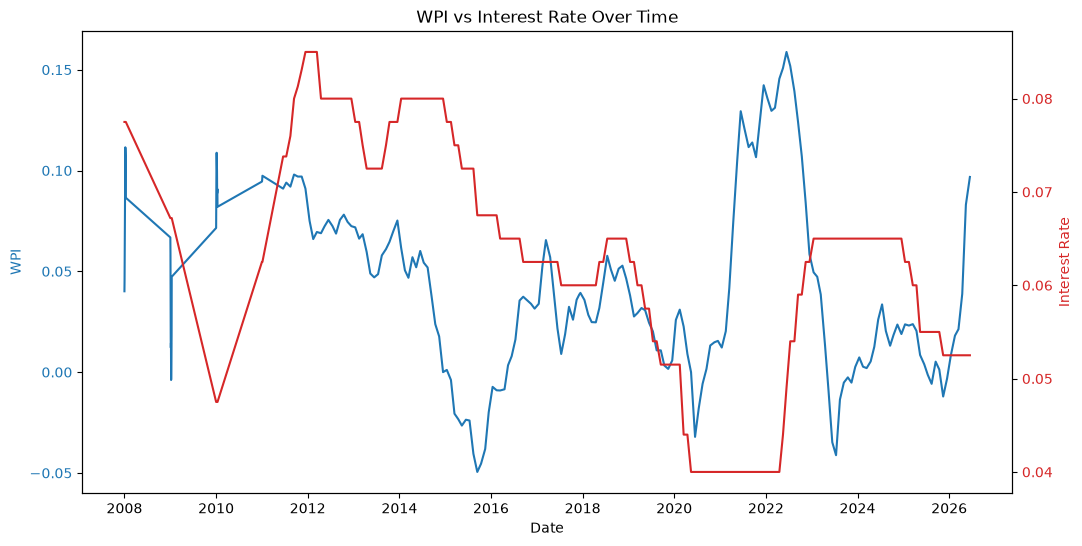

In [131]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# WPI
ax1.set_xlabel("Date")
ax1.set_ylabel("WPI", color="tab:blue")
ax1.plot(merged_df["release_date"], merged_df["wpi"], color="tab:blue", label="WPI")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Interest rate on second axis
ax2 = ax1.twinx()
ax2.set_ylabel("Interest Rate", color="tab:red")
ax2.plot(
    merged_df["release_date"],
    merged_df["interest_rate"],
    color="tab:red",
    label="Interest Rate")
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title("WPI vs Interest Rate Over Time")
plt.show()


Even though there is no strong correlation in numerical manner but if see in chart it appears WPI is following interest rates pattern not exactly but in same manner